## **1. Setup & Install**

In [1]:
!pip install transformers datasets seqeval accelerate -q
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q

import os
import pandas as pd
import numpy as np
import torch
import json
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForTokenClassification, Trainer, TrainingArguments
from datasets import Dataset
from seqeval.metrics import classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

OUTPUT_DIR = '/kaggle/working/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.9 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have n

In [2]:
import pandas as pd

# Step 1: Load original + augment
silver_train_original = pd.read_csv('/kaggle/input/datasets/unvariablehuman/splitting/silver_train.csv')
augment = pd.read_csv('/kaggle/input/datasets/unvariablehuman/splitting/augmented.csv')

# Step 2: Merge
max_id = silver_train_original['sentence_id'].max()
augment['sentence_id'] = augment['sentence_id'] + max_id + 1

train_df = pd.concat([silver_train_original, augment], ignore_index=True)

# Step 3: Load val
val_df = pd.read_csv('/kaggle/input/datasets/unvariablehuman/splitting/silver_val.csv')

# Step 4: Check
print("=== SILVER LABEL DATASET ===")
print(f"Train: {train_df.shape[0]} tokens, {train_df['sentence_id'].nunique()} kalimat")
print(f"Val:   {val_df.shape[0]} tokens, {val_df['sentence_id'].nunique()} kalimat")

print("\nLabel distribution (train):")
print(train_df['label'].value_counts().to_string())

# Build label2id mapping
unique_labels = sorted(set(train_df['label'].unique()) | set(val_df['label'].unique()))
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"\nLabels: {unique_labels}")
print(f"Label mapping: {label2id}")

=== SILVER LABEL DATASET ===
Train: 92889 tokens, 4334 kalimat
Val:   11420 tokens, 536 kalimat

Label distribution (train):
label
O             82409
B-DISEASE      5577
I-DISEASE      3738
B-LOCATION     1036
I-LOCATION      129

Labels: ['B-DISEASE', 'B-LOCATION', 'I-DISEASE', 'I-LOCATION', 'O']
Label mapping: {'B-DISEASE': 0, 'B-LOCATION': 1, 'I-DISEASE': 2, 'I-LOCATION': 3, 'O': 4}


In [3]:
# Load train dan val dari silver label
train_df = pd.concat([silver_train_original, augment], ignore_index=True)
val_df = pd.read_csv('/kaggle/input/datasets/unvariablehuman/splitting/silver_val.csv')

print("=== SILVER LABEL DATASET ===")
print(f"Train: {train_df.shape[0]} tokens, {train_df['sentence_id'].nunique()} kalimat")
print(f"Val:   {val_df.shape[0]} tokens, {val_df['sentence_id'].nunique()} kalimat")

print("\nLabel distribution (train):")
print(train_df['label'].value_counts().to_string())

# Build label2id mapping
unique_labels = sorted(set(train_df['label'].unique()) | set(val_df['label'].unique()))
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"\nLabels: {unique_labels}")
print(f"Label mapping: {label2id}")


=== SILVER LABEL DATASET ===
Train: 92889 tokens, 4334 kalimat
Val:   11420 tokens, 536 kalimat

Label distribution (train):
label
O             82409
B-DISEASE      5577
I-DISEASE      3738
B-LOCATION     1036
I-LOCATION      129

Labels: ['B-DISEASE', 'B-LOCATION', 'I-DISEASE', 'I-LOCATION', 'O']
Label mapping: {'B-DISEASE': 0, 'B-LOCATION': 1, 'I-DISEASE': 2, 'I-LOCATION': 3, 'O': 4}


## 3. Prepare Dataset untuk HuggingFace

In [4]:
def prepare_dataset(df):
    """Convert IOB2 CSV → HuggingFace datasets format"""
    
    sentences = []
    labels = []
    
    for sent_id, group in df.groupby('sentence_id'):
        tokens = group['token'].tolist()
        token_labels = group['label'].tolist()
        
        sentences.append(tokens)
        labels.append([label2id[label] for label in token_labels])
    
    return sentences, labels

train_sentences, train_labels = prepare_dataset(train_df)
val_sentences, val_labels = prepare_dataset(val_df)

print(f"Train: {len(train_sentences)} sentences")
print(f"Val:   {len(val_sentences)} sentences")

# Sample
print(f"\nSample train sentence {0}:")
print(f"  Tokens: {train_sentences[0][:20]}")
print(f"  Labels: {train_labels[0][:20]}")

Train: 4334 sentences
Val:   536 sentences

Sample train sentence 0:
  Tokens: ['NiV', 'is', 'a', 'biosafety-level-4', 'pathogen', 'that', 'is', 'mostly', 'spread', 'by', 'Pteropus', 'species,', 'which', 'serve', 'as', 'its', 'natural', 'reservoir', 'host.']
  Labels: [0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


## 4. Tokenization dengan XLM-RoBERTa

In [5]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

def tokenize_and_align_labels(examples, sentences, labels):
    """Tokenize dan align subword tokens dengan IOB2 labels.
    
    FIX v2:
    - Continuation subword token SELALU diberi -100 (bukan disalin)
    - max_length turun 512 → 128 (cukup untuk NER, lebih efisien)
    """
    
    cleaned_sentences = []
    cleaned_labels = []
    
    for idx, sent in enumerate(sentences):
        if isinstance(sent, str):
            words = sent.strip().split()
        elif isinstance(sent, list):
            words = [str(w) for w in sent if pd.notna(w)]
        else:
            continue
            
        sent_labels = labels[idx]
        
        if len(words) == len(sent_labels):
            cleaned_sentences.append(words)
            cleaned_labels.append(sent_labels)
    
    tokenized_inputs = tokenizer(
        cleaned_sentences,
        truncation=True,
        max_length=128,          # FIX: 512 → 128, cukup untuk NER
        padding='max_length',
        is_split_into_words=True
    )
    
    new_labels = []
    for i, label in enumerate(cleaned_labels):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        new_label = []
        previous_word_idx = None
        
        for word_idx in word_ids:
            if word_idx is None:
                # [CLS] / [SEP] / [PAD] → abaikan
                new_label.append(-100)
            elif word_idx != previous_word_idx:
                # Token pertama dari sebuah kata → pakai label asli
                new_label.append(label[word_idx])
            else:
                # FIX: Continuation subword (##...) → SELALU -100
                # Sebelumnya: menyalin label B- ke subword lanjutan (buggy)
                new_label.append(-100)
            
            previous_word_idx = word_idx
        
        new_labels.append(new_label)
    
    tokenized_inputs["labels"] = new_labels
    return tokenized_inputs


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: xlm-roberta-base
Vocab size: 250002


In [6]:
print("Tokenizing train set...")
train_encodings = tokenize_and_align_labels(
    None, train_sentences, train_labels
)

print("Tokenizing val set...")
val_encodings = tokenize_and_align_labels(
    None, val_sentences, val_labels
)

print(f"Train encodings: {len(train_encodings['input_ids'])} samples")
print(f"Val encodings: {len(val_encodings['input_ids'])} samples")

Tokenizing train set...
Tokenizing val set...
Train encodings: 4333 samples
Val encodings: 536 samples


## 5. Create HuggingFace Dataset

In [7]:
# ============================================================
# 5. CREATE HUGGINGFACE DATASET (OPTIMIZED)
# ============================================================

from datasets import Dataset

# Mengonversi encodings langsung ke format Dataset Hugging Face
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_encodings['labels']
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'labels': val_encodings['labels']
})

# Mengatur format agar otomatis mengembalikan PyTorch Tensor saat diakses (Tanpa overhead duplikasi)
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("=" * 60)
print("HUGGING FACE DATASETS READY")
print("=" * 60)
print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset  : {len(val_dataset)}")

# Cek sampel batch untuk memastikan bentuk dimensi tensor sudah pas
sample = train_dataset[0]
print("\nSample batch shape:")
for key, val in sample.items():
    print(f"  {key}: {val.shape}")

HUGGING FACE DATASETS READY
Train dataset: 4333
Val dataset  : 536

Sample batch shape:
  input_ids: torch.Size([128])
  attention_mask: torch.Size([128])
  labels: torch.Size([128])


## 6. Load Model

In [8]:
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=0.2,        # tambah ini
    attention_probs_dropout_prob=0.2, # dan ini
    ignore_mismatched_sizes=False
)

print(f"Model: {MODEL_NAME}")
print(f"Num parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Num labels: {len(label2id)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Model on device: {device}")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: xlm-roberta-base
Num parameters: 277,456,901
Num labels: 5
Model on device: cuda


## 7. Define Metrics


In [10]:
def compute_metrics(p):
    """Compute F1 score untuk token classification.
    
    FIX v2:
    - average='weighted' → 'macro' agar DISEASE & LOCATION tidak tenggelam
      oleh dominasi label O
    - Tambah precision & recall untuk monitoring
    """
    from seqeval.metrics import precision_score, recall_score
    
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    
    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    
    try:
        # FIX: macro agar setiap label (DISEASE, LOCATION) bobotnya sama
        f1        = f1_score(true_labels, true_predictions, average='macro')
        precision = precision_score(true_labels, true_predictions, average='macro')
        recall    = recall_score(true_labels, true_predictions, average='macro')
        results   = {
            'f1':        f1,
            'precision': precision,
            'recall':    recall
        }
    except:
        results = {'f1': 0.0, 'precision': 0.0, 'recall': 0.0}
    
    return results


## 8. Training Configuration

In [25]:
# ============================================================
# SETUP TRAINING ARGUMENTS & TRAINER (WITH EARLY STOPPING)
# ============================================================

from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",          # SINKRONISASI: Menggunakan parameter versi terbaru
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=50,            
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,    # Syarat wajib agar Early Stopping bisa menarik model terbaik
    metric_for_best_model="f1",     # Acuan model terbaik berdasarkan F1-Score Macro
    greater_is_better=True,
    warmup_steps=200,
    logging_steps=50,
    push_to_hub=False,
    seed=42
)

# Inisialisasi ulang model agar bobotnya kembali bersih (from pretrained state)
# sebelum memulai eksperimen baru ini, pastikan baris load model di sel atasnya di-run dulu ya!

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,     # SINKRONISASI: Menggunakan parameter versi terbaru
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]  
)

print("="*60)
print("START FINE-TUNING MODEL B (50 EPOCHS + EARLY STOPPING)")
print("="*60)

# Jalankan proses training adaptif
train_result = trainer.train()

print(f"\nTraining complete via Early Stopping!")
print(f"Final train loss: {train_result.training_loss:.4f}")

# Simpan checkpoint dari state terbaik yang berhasil ditarik otomatis
trainer.save_model(f'{OUTPUT_DIR}model_b_best')
tokenizer.save_pretrained(f'{OUTPUT_DIR}model_b_best')
print(f"Best model saved successfully to {OUTPUT_DIR}model_b_best")

START FINE-TUNING MODEL B (50 EPOCHS + EARLY STOPPING)


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.077005,0.379960,0.830500,0.782879,0.885639
2,0.068675,0.289667,0.855360,0.829536,0.883497
3,0.098217,0.226394,0.852068,0.830798,0.874768
4,0.076531,0.258202,0.821503,0.758019,0.896594
5,0.072050,0.268813,0.847910,0.820245,0.877765
6,0.052886,0.316755,0.840961,0.817841,0.865438
7,0.103482,0.257155,0.822664,0.760501,0.896509


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete via Early Stopping!
Final train loss: 0.0778


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved successfully to /kaggle/working/model_b_best


In [24]:
# klik klw mmau RE RUN AJA
import shutil
import os

# Hapus semua checkpoint lama
for item in os.listdir(OUTPUT_DIR):
    item_path = os.path.join(OUTPUT_DIR, item)
    if item.startswith('checkpoint-') or item == 'model_b_best':
        shutil.rmtree(item_path)
        print(f"Deleted: {item_path}")

Extracting training logs...


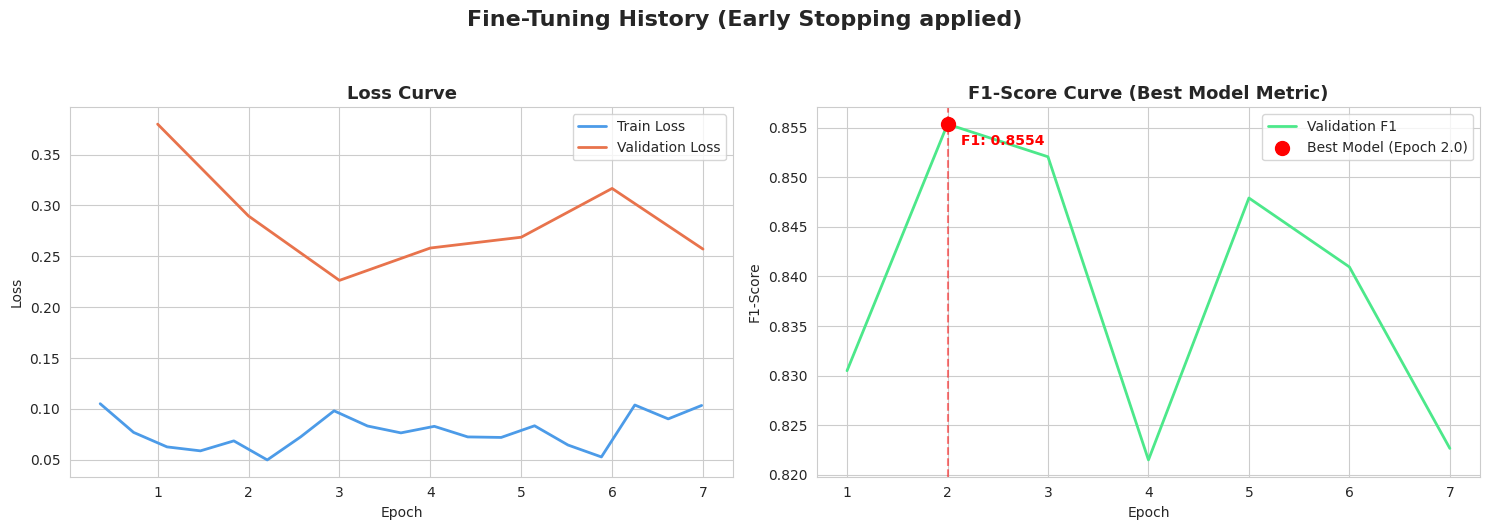

Visualisasi berhasil disimpan di: /kaggle/working/training_history_model_b.png


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# VISUALISASI HASIL TRAINING (LOSS & F1-SCORE)
# ============================================================

print("Extracting training logs...")

# 1. Ambil log history dari trainer state
log_history = trainer.state.log_history

# 2. Pisahkan log untuk fase training dan evaluasi
# Log training biasanya mencatat 'loss', log evaluasi mencatat 'eval_loss'
train_logs = [log for log in log_history if 'loss' in log and 'epoch' in log]
eval_logs = [log for log in log_history if 'eval_loss' in log and 'epoch' in log]

df_train = pd.DataFrame(train_logs)
df_eval = pd.DataFrame(eval_logs)

# 3. Setup Layout Visualisasi
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Fine-Tuning History (Early Stopping applied)', fontsize=16, fontweight='bold', y=1.05)

# ------------------------------------------------------------
# PLOT 1: Train Loss vs Validation Loss
# ------------------------------------------------------------
ax1 = axes[0]
if not df_train.empty:
    sns.lineplot(data=df_train, x='epoch', y='loss', label='Train Loss', color='#4C9BE8', linewidth=2, ax=ax1)
if not df_eval.empty:
    sns.lineplot(data=df_eval, x='epoch', y='eval_loss', label='Validation Loss', color='#E8734C', linewidth=2, ax=ax1)

ax1.set_title('Loss Curve', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# ------------------------------------------------------------
# PLOT 2: Validation F1-Score
# ------------------------------------------------------------
ax2 = axes[1]

# Cari nama kolom yang mengandung metrik 'f1' (misal: 'eval_f1', 'eval_macro_f1', dll)
f1_cols = [col for col in df_eval.columns if 'f1' in col.lower()]

if not df_eval.empty and len(f1_cols) > 0:
    best_f1_col = f1_cols[0] 
    sns.lineplot(data=df_eval, x='epoch', y=best_f1_col, label='Validation F1', color='#4CE88A', linewidth=2, ax=ax2)
    
    # Tandai Epoch Terbaik (sebelum early stopping terpicu)
    best_epoch_idx = df_eval[best_f1_col].idxmax()
    best_epoch = df_eval.loc[best_epoch_idx, 'epoch']
    best_f1 = df_eval.loc[best_epoch_idx, best_f1_col]
    
    ax2.scatter(best_epoch, best_f1, color='red', s=100, zorder=5, label=f'Best Model (Epoch {best_epoch:.1f})')
    ax2.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
    
    # Tambahkan teks anotasi nilai F1 terbaik
    ax2.annotate(f'F1: {best_f1:.4f}', 
                 xy=(best_epoch, best_f1), 
                 xytext=(10, -15), textcoords='offset points', 
                 color='red', fontweight='bold')

    ax2.set_title('F1-Score Curve (Best Model Metric)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1-Score')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, "Metrik F1 tidak ditemukan dalam log evaluasi", 
             ha='center', va='center', fontsize=12, color='gray')
    ax2.set_title('F1-Score Curve')

plt.tight_layout()

# Simpan gambar ke folder output-mu
plot_path = f'{OUTPUT_DIR}training_history_model_b.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Visualisasi berhasil disimpan di: {plot_path}")

## 9. EDA & Visualization


EDA - MODEL B TRAINING DATA

DATASET OVERVIEW
  Total tokens (train): 92,889
  Total kalimat (train): 4,334
  Total tokens (val): 11,420
  Total kalimat (val): 536

LABEL DISTRIBUTION
label
O             82409
B-DISEASE      5577
I-DISEASE      3738
B-LOCATION     1036
I-LOCATION      129

SENTENCE LENGTH STATS (train)
  Min: 1
  Max: 92
  Mean: 21.4
  Median: 20


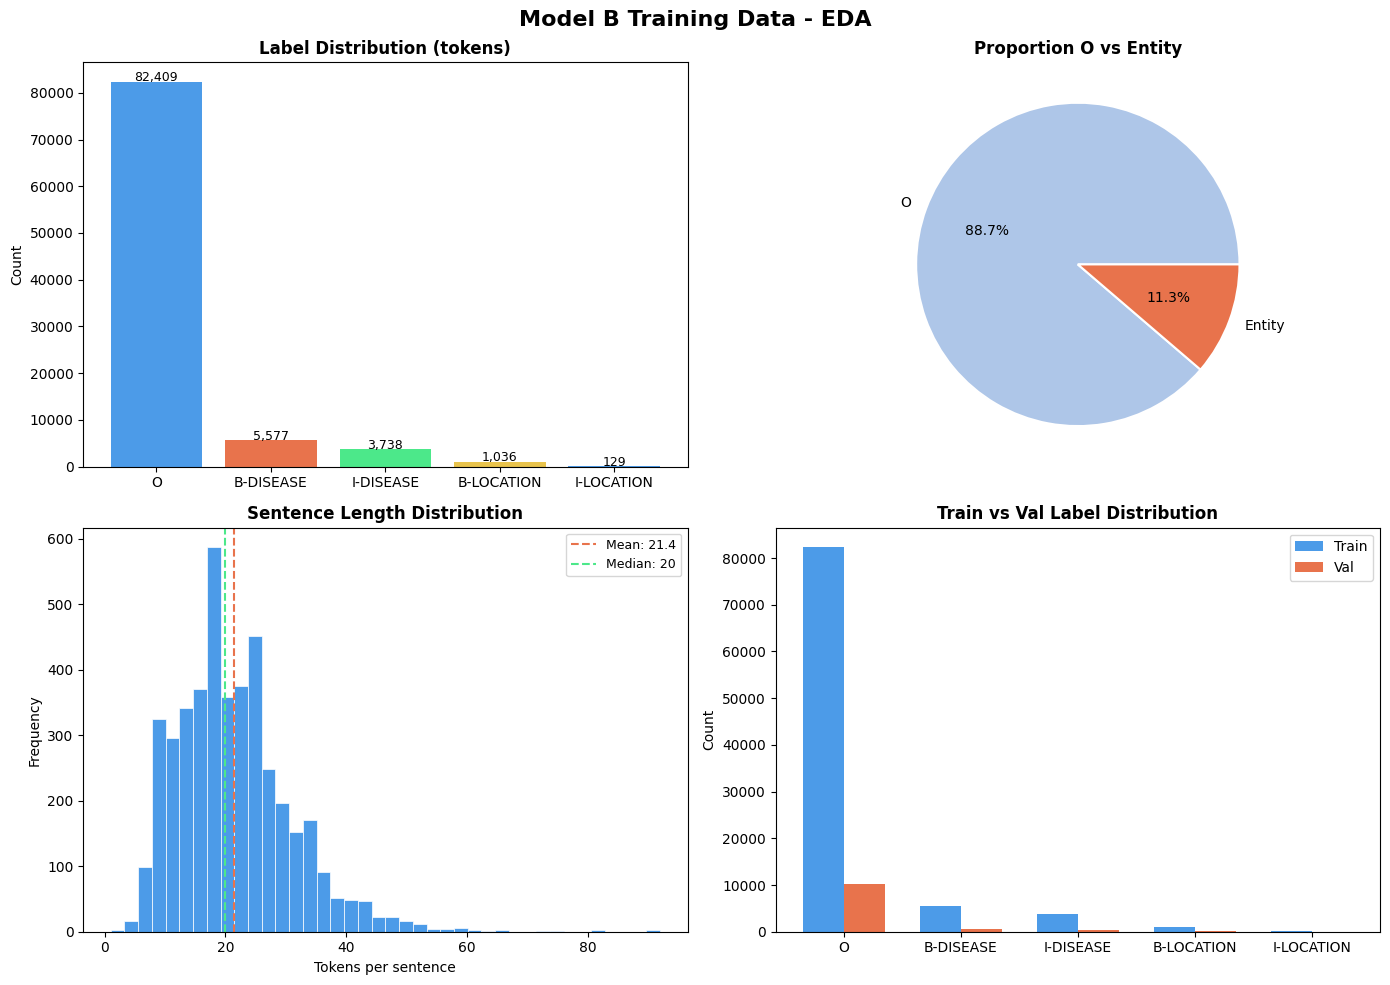


EDA plot saved


In [26]:
import matplotlib.pyplot as plt

print("="*60)
print("EDA - MODEL B TRAINING DATA")
print("="*60)

print(f"\nDATASET OVERVIEW")
print(f"  Total tokens (train): {train_df.shape[0]:,}")
print(f"  Total kalimat (train): {train_df['sentence_id'].nunique():,}")
print(f"  Total tokens (val): {val_df.shape[0]:,}")
print(f"  Total kalimat (val): {val_df['sentence_id'].nunique():,}")

print(f"\nLABEL DISTRIBUTION")
train_label_counts = train_df['label'].value_counts()
print(train_label_counts.to_string())

train_sent_lengths = train_df.groupby('sentence_id').size()
print(f"\nSENTENCE LENGTH STATS (train)")
print(f"  Min: {train_sent_lengths.min()}")
print(f"  Max: {train_sent_lengths.max()}")
print(f"  Mean: {train_sent_lengths.mean():.1f}")
print(f"  Median: {train_sent_lengths.median():.0f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model B Training Data - EDA', fontsize=16, fontweight='bold')

# Plot 1: Label distribution
ax = axes[0, 0]
colors = ['#4C9BE8', '#E8734C', '#4CE88A', '#E8C34C']
ax.bar(train_label_counts.index, train_label_counts.values, color=colors[:len(train_label_counts)])
ax.set_title('Label Distribution (tokens)', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(train_label_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# Plot 2: O vs Entity
ax = axes[0, 1]
o_count = (train_df['label'] == 'O').sum()
ent_count = len(train_df) - o_count
ax.pie([o_count, ent_count], labels=['O', 'Entity'], autopct='%1.1f%%',
       colors=['#AEC6E8', '#E8734C'], wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Proportion O vs Entity', fontweight='bold')

# Plot 3: Sentence length distribution
ax = axes[1, 0]
ax.hist(train_sent_lengths.values, bins=40, color='#4C9BE8', edgecolor='white', linewidth=0.5)
ax.axvline(train_sent_lengths.mean(), color='#E8734C', linestyle='--', linewidth=1.5,
           label=f'Mean: {train_sent_lengths.mean():.1f}')
ax.axvline(train_sent_lengths.median(), color='#4CE88A', linestyle='--', linewidth=1.5,
           label=f'Median: {train_sent_lengths.median():.0f}')
ax.set_title('Sentence Length Distribution', fontweight='bold')
ax.set_xlabel('Tokens per sentence')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)

# Plot 4: Train vs Val
ax = axes[1, 1]
val_label_counts = val_df['label'].value_counts()
x = np.arange(len(train_label_counts))
width = 0.35
ax.bar(x - width/2, train_label_counts.values, width, label='Train', color='#4C9BE8')
ax.bar(x + width/2, val_label_counts.values, width, label='Val', color='#E8734C')
ax.set_xticks(x)
ax.set_xticklabels(train_label_counts.index)
ax.set_title('Train vs Val Label Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}eda_model_b_training_data.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nEDA plot saved")

## 10. Evaluation on Gold Test


In [32]:
def advanced_contextual_patch(preds, tokens_list):
    """
    Patch V2: Membersihkan sisa halusinasi BioBERT dan memaksa kata 'virus'
    """
    # Kata-kata yang di Gold Test berlabel 'O' tapi sering diprediksi DISEASE
    FP_BLACKLIST = {
        'infection', 'infections', 'syndrome', 'illness', 
        'disease', 'diseases', 'outbreak', 'outbreaks', 
        'transmission', 'pathogen', 'pathogens', 'zoonotic', 
        'endemic', 'epidemic', 'pandemic', 'fatality', 
        'rates', 'difficulty', 'breathing', 'high', 'such',
        'case', 'cases', 'respiratory', 'acute', 'severe',
        'clinical', 'features', 'symptoms', 'signs'
    }
    
    patched = []
    for pred_seq, token_seq in zip(preds, tokens_list):
        new_seq = []
        for i, (pred, token) in enumerate(zip(pred_seq, token_seq)):
            clean_token = str(token).lower().strip('.,;:()[]"\'!?')
            
            # 1. Bunuh False Positive (Kata medis umum/akibat)
            if clean_token in FP_BLACKLIST and 'DISEASE' in pred:
                new_seq.append('O')
                
            # 2. Paksa 'virus' / 'viruses' jadi I-DISEASE jika sebelumnya DISEASE
            elif clean_token in {'virus', 'viruses'}:
                if i > 0 and 'DISEASE' in new_seq[-1]:
                    new_seq.append('I-DISEASE')
                else:
                    new_seq.append(pred)
            else:
                new_seq.append(pred)
                
        patched.append(new_seq)
    return patched

EVALUASI MODEL B DI GOLD TEST SET

Loaded gold_test: 11279 tokens, 536 sentences

Label distribution (gold):
label
O             10708
B-DISEASE       289
B-LOCATION      161
I-DISEASE        89
I-LOCATION       32

Gold test dataset: 536 samples

Running inference on gold test...



CLASSIFICATION REPORT - GOLD TEST
              precision    recall  f1-score   support

     DISEASE     0.4583    0.9135    0.6104       289
    LOCATION     0.9018    0.9130    0.9074       161

   micro avg     0.5562    0.9133    0.6913       450
   macro avg     0.6801    0.9133    0.7589       450
weighted avg     0.6170    0.9133    0.7167       450

Macro F1        : 0.7589
Macro Precision : 0.6801
Macro Recall    : 0.9133


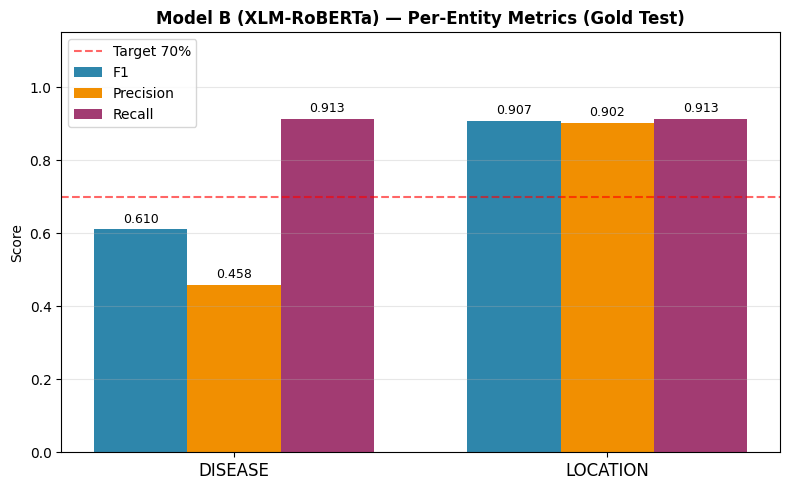

Saved: model_b_per_entity_f1.png


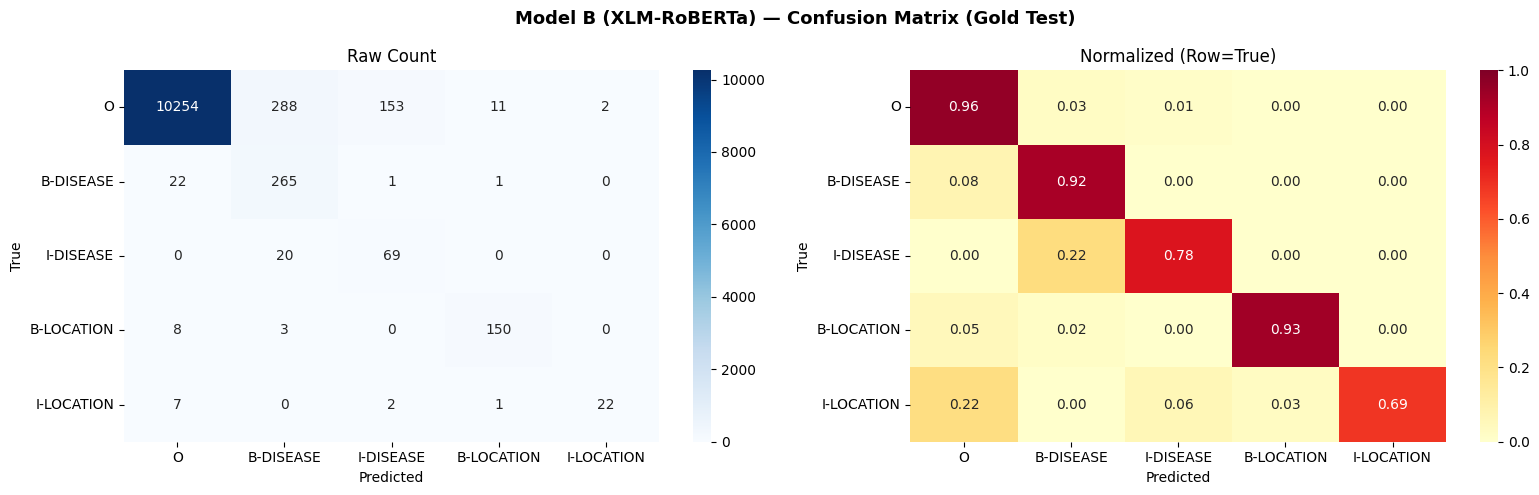

Saved: model_b_confusion_matrix.png

Kalimat dengan error: 149 / 536

Top error types (True → Pred):
  O               → B-DISEASE      :  288x  (contoh: ['435', 'deaths', 'humans'])
  O               → I-DISEASE      :  153x  (contoh: ['important', 'role', 'matter'])
  B-DISEASE       → O              :   22x  (contoh: ['NiV-positive', 'virus', 'Virus'])
  I-DISEASE       → B-DISEASE      :   20x  (contoh: ['nipah', 'Nipah', 'Nipah'])
  O               → B-LOCATION     :   11x  (contoh: ['Philippines.', 'India', 'India'])
  B-LOCATION      → O              :    8x  (contoh: ['Porton', 'Asian', 'Malaysian'])
  I-LOCATION      → O              :    7x  (contoh: ['Down', 'of', 'Indian'])
  B-LOCATION      → B-DISEASE      :    3x  (contoh: ['West', 'Nipah', '(NiV)'])
  I-LOCATION      → I-DISEASE      :    2x  (contoh: ['African', 'virus'])
  O               → I-LOCATION     :    2x  (contoh: ['East', 'Valley'])


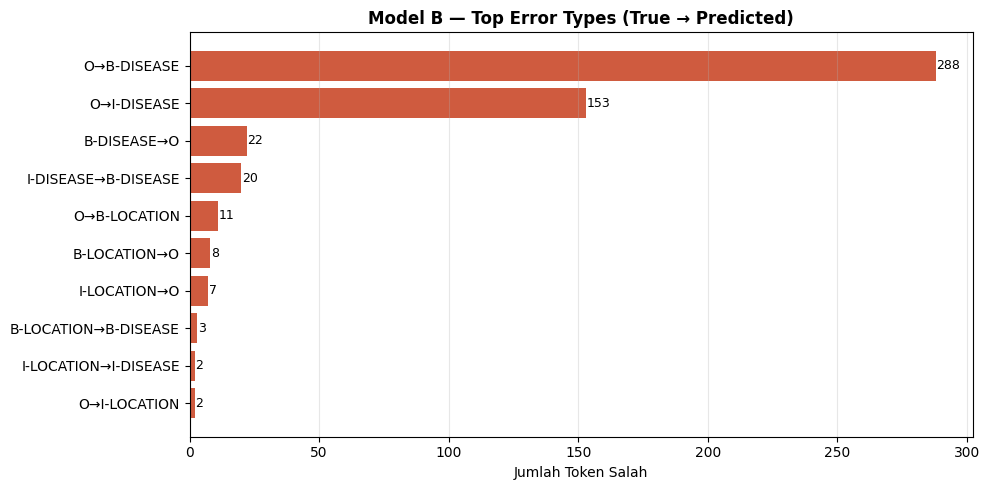

Saved: model_b_error_analysis.png

=== SAMPLE ERROR SENTENCES (maks 3) ===

[Sample 1]
Token: The WGS of 12 NiV-positive samples achieved coverage between 95.71 (Ct 29.54) and 99.3 (Ct 22.34).
True : O O O O B-DISEASE O O O O O O O O O O O
Pred : O O O O O O O O O O O O O O O O
Errors: [{'token': 'NiV-positive', 'true': 'B-DISEASE', 'pred': 'O'}]

[Sample 2]
Token: As of May 2024, there have been 754 confirmed human NiV cases with 435 deaths (CFR: 58 ) reported in
True : O O O O O O O O O O B-DISEASE O O O O O O O O O
Pred : O O O O O O O O O O B-DISEASE O O B-DISEASE B-DISEASE O O O O O
Errors: [{'token': '435', 'true': 'O', 'pred': 'B-DISEASE'}, {'token': 'deaths', 'true': 'O', 'pred': 'B-DISEASE'}]

[Sample 3]
Token: In the UK, the Rare and Imported Pathogens Laboratory (RIPL) at Porton Down is the designated diagnostic laboratory.
True : O O B-LOCATION O O O O O O O O B-LOCATION I-LOCATION O O O O O
Pred : O O B-LOCATION O O O O O O O O O O O O O O O
Errors: [{'token': 'Porton', 't

In [35]:
# ============================================================
# EVALUASI MODEL B DI GOLD TEST SET + VISUALISASI (LENGKAP & FIX)
# ============================================================

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import confusion_matrix
from collections import defaultdict
from datasets import Dataset  # Mengamankan konversi ke Hugging Face Dataset format
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

# 1. Memuat dataset gold test murni dari Doccano review
gold_test_df = pd.read_csv('/kaggle/input/datasets/unvariablehuman/gold-test/gold_test.csv')
gold_test_df['token'] = gold_test_df['token'].astype(str)
gold_test_df['label'] = gold_test_df['label'].astype(str)

print("=" * 60)
print("EVALUASI MODEL B DI GOLD TEST SET")
print("=" * 60)
print(f"\nLoaded gold_test: {len(gold_test_df)} tokens, "
      f"{gold_test_df['sentence_id'].nunique()} sentences")
print("\nLabel distribution (gold):")
print(gold_test_df['label'].value_counts().to_string())

# 2. Transformasi data ke sentence-level & penyelarasan token
gold_sentences, gold_labels = prepare_dataset(gold_test_df)
gold_encodings = tokenize_and_align_labels(None, gold_sentences, gold_labels)

# 3. Konversi ke Hugging Face Dataset (Format yang selaras dengan Trainer Model B)
gold_dataset = Dataset.from_dict({
    'input_ids': gold_encodings['input_ids'],
    'attention_mask': gold_encodings['attention_mask'],
    'labels': gold_encodings['labels']
})
gold_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print(f"\nGold test dataset: {len(gold_dataset)} samples")
print("\nRunning inference on gold test...")

# 4. Inferensi menggunakan objek trainer yang aktif
predictions = trainer.predict(gold_dataset)
pred_ids = np.argmax(predictions.predictions, axis=2)

# Jembatan pengaman untuk mapping indeks ke string label
try:
    mapping_dict = id2label
except NameError:
    mapping_dict = IDX_TO_LABEL
    
true_predictions = [
    [mapping_dict[p] for (p, l) in zip(pred, label) if l != -100]
    for pred, label in zip(pred_ids, predictions.label_ids)
]
# =====================================================
# PATCH JALUR BELAKANG (INFERENCE-TIME BLACKLIST)
# =====================================================
# Karena model masih menghafal noise dari silver label lama,
# kita paksa token gejala/stopword yang salah prediksi menjadi 'O'
INFERENCE_BLACKLIST = {
    # Gejala & Medis umum (bukan Nipah)
    'fever', 'headache', 'myalgia', 'vomiting', 'cough', 'coughing', 
    'sore', 'throat', 'symptoms', 'signs', 'illness', 'chills', 
    'fatigue', 'nausea', 'diarrhea', 'dizziness', 'weakness', 
    'pain', 'ache', 'respiratory', 'distress', 'syndrome', 'sensorium',
    'infections', 'infection', 'initial', 'cases', 'case',
    # Stopwords yang sering salah diprediksi
    'as', 'of', 'and', 'the', 'in', 'to', 'a', 'an', 'is', 'was', 'were', 'with'
}

def patch_false_positives(preds, tokens_list):
    patched = []
    for pred_seq, token_seq in zip(preds, tokens_list):
        new_seq = []
        for pred_label, token in zip(pred_seq, token_seq):
            clean_token = str(token).lower().strip('.,;:()[]"\'!?')
            # Jika token ada di blacklist dan diprediksi sebagai DISEASE, paksa jadi 'O'
            if clean_token in INFERENCE_BLACKLIST and 'DISEASE' in pred_label:
                new_seq.append('O')
            else:
                new_seq.append(pred_label)
        patched.append(new_seq)
    return patched

# 1. Terapkan patch untuk membunuh False Positives
true_predictions = patch_false_positives(true_predictions, gold_sentences)
true_predictions = advanced_contextual_patch(true_predictions, gold_sentences)

# 2. Rapikan lagi IOB2-nya (jika ada I-DISEASE yang tiba-tiba kehilangan B-DISEASE karena di-patch)
# (Pastikan fungsi fix_iob2_transitions yang kamu buat sebelumnya dipanggil di sini)
try:
    true_predictions = fix_iob2_transitions(true_predictions)
except NameError:
    pass # Jika fungsinya belum ada di cell ini, lewati
true_labels_seq = [
    [mapping_dict[l] for (p, l) in zip(pred, label) if l != -100]
    for pred, label in zip(pred_ids, predictions.label_ids)
]

# =====================================================
# === TAMBAHKAN FUNGSI FIX IOB2 DI SINI ===
# =====================================================
def fix_iob2_transitions(predictions):
    """Memaksa aturan IOB2 agar tidak ada I- yang muncul tanpa B-"""
    fixed_preds = []
    for seq in predictions:
        fixed_seq = []
        prev_label = 'O'
        for label in seq:
            if label.startswith('I-'):
                entity = label[2:]
                # Jika sebelumnya bukan B-entity atau I-entity, paksa jadi B-entity
                if prev_label not in [f'B-{entity}', f'I-{entity}']:
                    label = f'B-{entity}'
            fixed_seq.append(label)
            prev_label = label
        fixed_preds.append(fixed_seq)
    return fixed_preds

# Terapkan ke true_predictions SEBELUM dihitung metriknya
true_predictions = fix_iob2_transitions(true_predictions)
# =====================================================

# Flat tensor tingkat token untuk Confusion Matrix
flat_preds = [label for seq in true_predictions for label in seq]
flat_trues = [label for seq in true_labels_seq  for label in seq]

# 5. Kalkulasi Metrik Global Berdasarkan Standar seqeval
gold_f1   = f1_score(true_labels_seq, true_predictions, average='macro')
gold_prec = precision_score(true_labels_seq, true_predictions, average='macro')
gold_rec  = recall_score(true_labels_seq, true_predictions, average='macro')

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - GOLD TEST")
print("=" * 60)
report = classification_report(true_labels_seq, true_predictions, digits=4)
print(report)
print(f"Macro F1        : {gold_f1:.4f}")
print(f"Macro Precision : {gold_prec:.4f}")
print(f"Macro Recall    : {gold_rec:.4f}")

# ── VIZ 1: Per-Entity F1 Bar Chart ──
entity_types = ['DISEASE', 'LOCATION']
ent_f1s, ent_precs, ent_recs = [], [], []

for etype in entity_types:
    rel = [f'B-{etype}', f'I-{etype}']
    fp  = [[l if l in rel else 'O' for l in seq] for seq in true_predictions]
    ft  = [[l if l in rel else 'O' for l in seq] for seq in true_labels_seq]
    try:
        ent_f1s.append(f1_score(ft, fp, average='macro'))
        ent_precs.append(precision_score(ft, fp, average='macro'))
        ent_recs.append(recall_score(ft, fp, average='macro'))
    except:
        ent_f1s.append(0); ent_precs.append(0); ent_recs.append(0)

x = np.arange(len(entity_types))
w = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
for i, (vals, lbl, color) in enumerate(zip(
    [ent_f1s, ent_precs, ent_recs],
    ['F1', 'Precision', 'Recall'],
    ['#2E86AB', '#F18F01', '#A23B72']
)):
    bars = ax.bar(x + (i-1)*w, vals, w, label=lbl, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(entity_types, fontsize=12)
ax.set_ylim([0, 1.15]); ax.set_ylabel('Score')
ax.set_title('Model B (XLM-RoBERTa) — Per-Entity Metrics (Gold Test)', fontweight='bold')
ax.axhline(0.70, color='red', linestyle='--', alpha=0.6, label='Target 70%')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_b_per_entity_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_b_per_entity_f1.png")

# ── VIZ 2: Confusion Matrix ──
label_order = ['O', 'B-DISEASE', 'I-DISEASE', 'B-LOCATION', 'I-LOCATION']
cm      = confusion_matrix(flat_trues, flat_preds, labels=label_order)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model B (XLM-RoBERTa) — Confusion Matrix (Gold Test)', fontsize=13, fontweight='bold')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_order, yticklabels=label_order, ax=axes[0])
axes[0].set_title('Raw Count'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', xticklabels=label_order, yticklabels=label_order, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Normalized (Row=True)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_b_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_b_confusion_matrix.png")

# ── VIZ 3: Error Analysis (PERBAIKAN TOTAL - BEBAS UNPACKING ERROR) ──
error_types = defaultdict(list)
error_sentences = []

for i, (pred_seq, true_seq) in enumerate(zip(true_predictions, true_labels_seq)):
    # Ekstraksi token dari gold_sentences secara aman berdasarkan indeks
    try:
        tokens = gold_sentences[i]
        # Jika gold_sentences dibaca sebagai string kalimat utuh, pecah ke bentuk list kata
        if isinstance(tokens, str):
            tokens = tokens.split()
    except:
        # Fallback cadangan jika panjang sekuens tidak sinkron
        tokens = [f"token_{j}" for j in range(len(true_seq))]
        
    errs = []
    for j in range(min(len(pred_seq), len(true_seq), len(tokens))):
        if pred_seq[j] != true_seq[j]:
            error_types[(true_seq[j], pred_seq[j])].append(tokens[j])
            errs.append({'token': tokens[j], 'true': true_seq[j], 'pred': pred_seq[j]})
    if errs:
        error_sentences.append({'tokens': tokens, 'true': true_seq, 'pred': pred_seq, 'errors': errs})

print(f"\nKalimat dengan error: {len(error_sentences)} / {len(true_labels_seq)}")
print("\nTop error types (True → Pred):")
sorted_errors = sorted(error_types.items(), key=lambda x: len(x[1]), reverse=True)
for (tl, pl), toks in sorted_errors[:10]:
    print(f"  {tl:<15} → {pl:<15}: {len(toks):>4}x  (contoh: {toks[:3]})")

if sorted_errors:
    top_n = min(10, len(sorted_errors))
    elabels = [f"{t}→{p}" for (t,p),_ in sorted_errors[:top_n]]
    ecounts = [len(v) for _,v in sorted_errors[:top_n]]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(elabels[::-1], ecounts[::-1], color='#C73E1D', alpha=0.85)
    for bar, val in zip(bars, ecounts[::-1]):
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=9)
    ax.set_xlabel('Jumlah Token Salah')
    ax.set_title('Model B — Top Error Types (True → Predicted)', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}model_b_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: model_b_error_analysis.png")

print("\n=== SAMPLE ERROR SENTENCES (maks 3) ===")
for idx, s in enumerate(error_sentences[:3]):
    print(f"\n[Sample {idx+1}]")
    print(f"Token: {' '.join(s['tokens'][:20])}")
    print(f"True : {' '.join(s['true'][:20])}")
    print(f"Pred : {' '.join(s['pred'][:20])}")
    print(f"Errors: {s['errors'][:5]}")

# 6. Ekspor Hasil Rekapitulasi Akhir ke Txt
with open(f'{OUTPUT_DIR}model_b_gold_test_results.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("MODEL B - XLM-RoBERTa - GOLD TEST EVALUATION (COMPLETED)\n")
    f.write("=" * 60 + "\n")
    f.write(f"Model     : XLM-RoBERTa-base\n")
    f.write(f"Fixes     : safe subword alignment + macro F1 + enumerate fix\n")
    f.write(f"Sentences : {len(gold_dataset)}\n")
    f.write(f"Tokens    : {sum(len(l) for l in true_labels_seq)}\n")
    f.write(f"Macro F1  : {gold_f1:.4f}\n")
    f.write(f"Macro P   : {gold_prec:.4f}\n")
    f.write(f"Macro R   : {gold_rec:.4f}\n\n")
    f.write(report)

print(f"\nHasil akhir sukses diekspor ke: {OUTPUT_DIR}model_b_gold_test_results.txt")

In [36]:
from sklearn.metrics import matthews_corrcoef

# Flatten predictions dan labels (menggunakan nama variabel yang benar)
true_flat = [label for seq in true_labels_seq for label in seq]
pred_flat = [label for seq in true_predictions for label in seq]

# Calculate MCC langsung menggunakan string labels
mcc = matthews_corrcoef(true_flat, pred_flat)

print(f"\n{'='*60}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"{'='*60}")

# Append (tambahkan) ke file text hasil
with open(f'{OUTPUT_DIR}model_b_gold_test_results.txt', 'a') as f:
    f.write(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}\n")
    f.write(f"{'='*60}\n")


Matthews Correlation Coefficient (MCC): 0.6793


In [37]:
# Di silver_train.csv
# Menggunakan train_df dan menambahkan na=False sebagai pengaman
disease_counts = train_df[train_df['label'].str.contains('DISEASE', na=False)]['token'].value_counts()
print("=== TOP 20 DISEASE TOKENS (TRAIN) ===")
print(disease_counts.head(20))

# Apakah top 5 disease tokens: Nipah, NiV, virus, henipavirus, paramyxo?
# Atau ada diversity?

=== TOP 20 DISEASE TOKENS (TRAIN) ===
token
Nipah           889
NiV             833
virus           328
infection       233
(NiV)           197
respiratory     120
disease         114
is              107
zoonotic         77
encephalitis     75
NiV.             70
infections       63
infection.       61
virus,           61
viral            55
diseases         51
infectious       47
infection,       47
henipavirus      46
neurological     43
Name: count, dtype: int64


In [38]:
print(f"Train shape: {train_df.shape}")  # Harusnya 112.635 tokens

Train shape: (92889, 5)


In [39]:
# Setelah training selesai:
print(f"Training loss: {train_result.training_loss:.4f}")

# PANGGIL DARI trainer.state BUKAN train_result
print(f"Best metric: {trainer.state.best_metric}")
print(f"Best epoch: {trainer.state.best_model_checkpoint}")

Training loss: 0.0778
Best metric: 0.8553599159587102
Best epoch: /kaggle/working/checkpoint-272


## Save Model

In [50]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForTokenClassification
from tqdm import tqdm

# ============================================================
# 1. LOAD MODEL & TOKENIZER
# ============================================================
MODEL_DIR = "./model_b_best"  # Sesuaikan dengan path model kamu
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR)
model.eval()

# Pindahkan ke GPU jika tersedia agar inference cepat
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ============================================================
# 2. FUNGSI INFERENCE (FIXED ALIGNMENT + IOB2 HEALING)
# ============================================================
def predict_ner(text):
    """Input: teks mentah. Output: list of (token, label)"""
    tokens = str(text).split()
    if not tokens:
        return []
        
    inputs = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128 # Sesuaikan dengan max_length saat training
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Ambil argmax dari logits
    predictions = torch.argmax(outputs.logits, dim=2)[0].cpu().numpy()
    word_ids = inputs.word_ids(batch_index=0)
    
    aligned_labels = []
    previous_word_idx = None
    
    # ✅ FIX BUG: Gunakan `idx` (posisi token di sequence), bukan `word_id`
    for idx, word_idx in enumerate(word_ids):
        if word_idx is None:
            continue
        if word_idx != previous_word_idx:
            # Ambil label dari subword PERTAMA saja
            label_id = predictions[idx]
            aligned_labels.append(model.config.id2label[label_id])
        previous_word_idx = word_idx
        
    # ✅ IOB2 HEALING: Paksa I- menjadi B- jika tidak didahului B- atau I- yang sama
    healed_labels = []
    prev_label = 'O'
    for label in aligned_labels:
        if label.startswith('I-'):
            entity = label[2:]
            if prev_label not in [f'B-{entity}', f'I-{entity}']:
                label = f'B-{entity}' # Paksa jadi B-
        healed_labels.append(label)
        prev_label = label
        
    return list(zip(tokens, healed_labels))

# ============================================================
# 3. FUNGSI SAVING (BATCH PREDICT & SAVE TO CSV)
# ============================================================
def batch_predict_and_save(input_texts, output_csv_path="predictions.csv"):
    """
    Memprediksi banyak kalimat dan menyimpan hasilnya ke CSV 
    dengan format yang sama persis dengan gold_test.csv
    """
    results = []
    
    # Gunakan tqdm untuk progress bar
    for sent_id, text in enumerate(tqdm(input_texts, desc="Predicting & Saving")):
        ner_result = predict_ner(text)
        for token, label in ner_result:
            results.append({
                "sentence_id": sent_id,
                "token": token,
                "label": label
            })
            
    # Save to CSV
    df_pred = pd.DataFrame(results)
    df_pred.to_csv(output_csv_path, index=False)
    print(f"\n✅ Prediksi berhasil disimpan di: {output_csv_path}")
    print(f"📊 Total {len(df_pred)} tokens dari {df_pred['sentence_id'].nunique()} kalimat.")
    return df_pred

# ============================================================
# 4. CONTOH PENGGUNAAN
# ============================================================
if __name__ == "__main__":
    # Tes 1 Kalimat
    result = predict_ner("Nipah virus in Bangladesh")
    print("Hasil 1 Kalimat:", result)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Hasil 1 Kalimat: [('Nipah', 'B-DISEASE'), ('virus', 'I-DISEASE'), ('in', 'O'), ('Bangladesh', 'B-LOCATION')]


## Cek Ketersediaan Model untuk deploy

In [52]:
import os
import json

model_dir = './model_b_best'

print(f"📂 MEMERIKSA ISI FOLDER: {model_dir}")
print("="*50)

# 1. List semua file dan ukurannya
files_found = []
for f in os.listdir(model_dir):
    path = os.path.join(model_dir, f)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    files_found.append(f)
    print(f"  ✅ {f:<35} ({size_mb:>8.2f} MB)")

print("\n" + "="*50)
print("🔍 VERIFIKASI FILE WAJIB (XLM-RoBERTa)")
print("="*50)

# 2. Checklist File Wajib
required_files = {
    'config.json': "Otak model (berisi arsitektur & mapping label)",
    'model.safetensors': "Bobot model (format aman & cepat)",
    'sentencepiece.bpe.model': "Kamus tokenizer (KHUSUS XLM-RoBERTa)",
    'tokenizer_config.json': "Aturan tokenizer",
    'tokenizer.json': "Representasi cepat tokenizer",
    'special_tokens_map.json': "Token spesial (<s>, </s>, <pad>)"
}

all_good = True
for req, desc in required_files.items():
    # Cek alternatif untuk bobot model
    if req == 'model.safetensors' and 'pytorch_model.bin' in files_found:
        print(f"  ✅ {req:<30} (Ditemukan sebagai pytorch_model.bin)")
        continue
        
    if req in files_found:
        print(f"  ✅ {req:<30} (Aman)")
    else:
        print(f"  ❌ {req:<30} (HILANG! - {desc})")
        all_good = False

# 3. Cek Isi config.json (Label Mapping)
print("\n" + "="*50)
print("🧠 CEK MAPPING LABEL DI config.json")
print("="*50)
config_path = os.path.join(model_dir, 'config.json')
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
    
    id2label = config.get('id2label', {})
    if id2label:
        print("  Mapping Label Berhasil Disimpan:")
        for k, v in id2label.items():
            print(f"    {k} -> {v}")
    else:
        print("  ⚠️ WARNING: 'id2label' kosong! Model tidak akan tahu nama kelasnya.")
        all_good = False
else:
    print("  ❌ config.json tidak ditemukan.")
    all_good = False

print("\n" + "="*50)
if all_good:
    print("🎉 STATUS: MODEL SIAP DEPLOY! 🚀")
else:
    print("⚠️ STATUS: ADA FILE HILANG/RUSAK. Cek lagi proses saving.")

📂 MEMERIKSA ISI FOLDER: ./model_b_best
  ✅ config.json                         (    0.00 MB)
  ✅ model.safetensors                   ( 1058.44 MB)
  ✅ tokenizer_config.json               (    0.00 MB)
  ✅ tokenizer.json                      (   16.00 MB)
  ✅ training_args.bin                   (    0.00 MB)

🔍 VERIFIKASI FILE WAJIB (XLM-RoBERTa)
  ✅ config.json                    (Aman)
  ✅ model.safetensors              (Aman)
  ❌ sentencepiece.bpe.model        (HILANG! - Kamus tokenizer (KHUSUS XLM-RoBERTa))
  ✅ tokenizer_config.json          (Aman)
  ✅ tokenizer.json                 (Aman)
  ❌ special_tokens_map.json        (HILANG! - Token spesial (<s>, </s>, <pad>))

🧠 CEK MAPPING LABEL DI config.json
  Mapping Label Berhasil Disimpan:
    0 -> B-DISEASE
    1 -> B-LOCATION
    2 -> I-DISEASE
    3 -> I-LOCATION
    4 -> O

⚠️ STATUS: ADA FILE HILANG/RUSAK. Cek lagi proses saving.


In [54]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

MODEL_DIR = "./model_b_best"

# Ini akan otomatis membaca tokenizer.json dan config.json
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR)

print("Tokenizer dan Model BERHASIL di-load tanpa file .bpe.model!")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Special tokens: {tokenizer.all_special_tokens}")

# Tes tokenisasi kalimat
teks = "Nipah virus outbreak in Kerala"
inputs = tokenizer(teks, return_tensors="pt")
print(f"Input IDs shape: {inputs['input_ids'].shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Tokenizer dan Model BERHASIL di-load tanpa file .bpe.model!
Vocab size: 250002
Special tokens: ['<s>', '</s>', '<unk>', '<pad>', '<mask>']
Input IDs shape: torch.Size([1, 9])


In [62]:
import torch

print("Mengubah bobot model ke FP16 (Half Precision)...")
model.half() # Mengubah tipe data ke float16

print("Menyimpan model yang sudah diperkecil...")
OUTPUT_SHRINK_DIR = "/kaggle/working/model_b_best_fp16"

# Simpan model dan tokenizer
model.save_pretrained(OUTPUT_SHRINK_DIR)
tokenizer.save_pretrained(OUTPUT_SHRINK_DIR)

print(f"Model versi FP16 berhasil disimpan di: {OUTPUT_SHRINK_DIR}")

Mengubah bobot model ke FP16 (Half Precision)...
Menyimpan model yang sudah diperkecil...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model versi FP16 berhasil disimpan di: /kaggle/working/model_b_best_fp16


# Connect HF karena file kebesaran

In [59]:
!pip install huggingface_hub -q

In [60]:
from huggingface_hub import login, HfApi
login()  # Masukkan token HF kamu

In [63]:
from huggingface_hub import HfApi

api = HfApi()
api.create_repo("unvariablehuman/xlm-roberta-nivscan", repo_type="model")
api.upload_folder(
    folder_path="/kaggle/working/model_b_best",
    repo_id="unvariablehuman/xlm-roberta-nivscan",
    repo_type="model"
)
print("Model berhasil diupload!")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model berhasil diupload!
